In [1]:
import torch
import matplotlib.pyplot as plt

from metashapes.shape import Ellipse, Cross, Star, Rectangle
from dispertorch import material, list_materials, ConstantEps

from metarcwa.model.lattice import Lattice
from metarcwa.model.layer import Layer
from metarcwa.model.stack import Stack
from metarcwa.model.source import PlaneWave
from metarcwa.model.utils import from_metashapes, from_dispertorch
from metarcwa.model.base import Model

from metarcwa.solver.harmonics import reciprocal_lattice_vectors, reciprocal_index_map, harmonic_index_map, harmonic_wavevectors
from metarcwa.solver.homogeneous import homogeneous_modes

print("materials:", sorted(list_materials().keys()))

materials: ['Ag', 'Al', 'Au', 'Cu', 'Si3N4', 'SiO2', 'TiO2', 'aSi', 'cSi']


In [7]:
P = 400.0                 # square period (nm)
GRID = (128, 128)         # (Nx, Ny) real-space sampling
M, N = 15, 15               # Fourier truncation: |m|<=M (a1), |n|<=N (a2)
WL = torch.linspace(400, 800, 41)                # wavelength (nm)

# Create Lattice
lattice = Lattice.rectangular(P, P)

# Geometry (metashapes) — an anisotropic, rotated ellipse makes the TVF interesting
shape = Rectangle(center=torch.tensor([P / 2, P / 2]),
                size=torch.tensor([150.0, 90.0]),
                angle=torch.tensor(0.0))

# Materials (dispertorch): crystalline-Si inclusion in air
solid = material("aSi")
void  = ConstantEps(1.0)

layer = Layer(
        eps_solid_fn=from_dispertorch(solid),
        thickness=torch.tensor(200.0),
        eps_void_fn=from_dispertorch(void),
        shape_fn=from_metashapes(shape, soft=False, softness=1.0),
    )

stack = Stack(
    incidence=from_dispertorch(ConstantEps(4.0)),
    layers=[layer],
    transmission=from_dispertorch(solid),
    lattice=lattice,
    grid_shape=GRID,
)

eps_grid (401, 128, 128) torch.complex64 | Re(eps) in [1.00, 18.73]


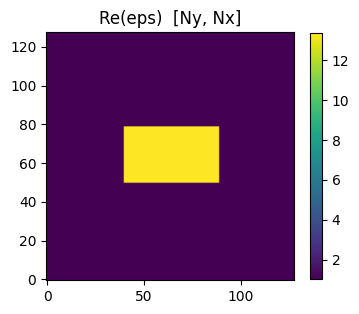

In [3]:
spec = stack.spec(WL)

eps_grid, a1, a2 = spec.layer_eps[0], spec.a1, spec.a2 
print("eps_grid", tuple(eps_grid.shape), eps_grid.dtype,
      "| Re(eps) in [%.2f, %.2f]" % (eps_grid.real.min(), eps_grid.real.max()))

plt.figure(figsize=(4, 4))
plt.imshow(eps_grid[0].real.cpu(), origin="lower", cmap="viridis")
plt.title("Re(eps)  [Ny, Nx]"); plt.colorbar(shrink=0.8); plt.show()

In [8]:
DTYPE = torch.float32
DEVICE = 'cuda:0'

# Build source
s_amp = 1.0
p_amp = 0.0
theta = 0.0
phi = 0.0

source = PlaneWave(WL, s_amp, p_amp, theta, phi)

# Create model
model = Model(stack, source)
model = model.to(dtype = DTYPE, device = DEVICE)
model_spec = model.spec()

# Get variables
kx0 = model_spec.source.kx0
ky0 = model_spec.source.ky0
a1 = model_spec.stack.a1
a2 = model_spec.stack.a2
eps_inc = (1 + 0j)*model_spec.stack.eps_incidence

# Compute kx and ky
b1, b2 = reciprocal_lattice_vectors(a1, a2)
m, n = harmonic_index_map(M, N, device=DEVICE)
Gx, Gy = reciprocal_index_map(m, n, b1, b2)
kx, ky = harmonic_wavevectors(kx0, ky0, Gx, Gy)
print(kx, kx.shape)

tensor([[[[-0.2356, -0.2199, -0.2042,  ...,  0.2042,  0.2199,  0.2356]]],


        [[[-0.2356, -0.2199, -0.2042,  ...,  0.2042,  0.2199,  0.2356]]],


        [[[-0.2356, -0.2199, -0.2042,  ...,  0.2042,  0.2199,  0.2356]]],


        ...,


        [[[-0.2356, -0.2199, -0.2042,  ...,  0.2042,  0.2199,  0.2356]]],


        [[[-0.2356, -0.2199, -0.2042,  ...,  0.2042,  0.2199,  0.2356]]],


        [[[-0.2356, -0.2199, -0.2042,  ...,  0.2042,  0.2199,  0.2356]]]],
       device='cuda:0') torch.Size([41, 1, 1, 961])


In [9]:
# Compute modes and eigenvalues
lam, W, V = homogeneous_modes(eps_inc, kx, ky)


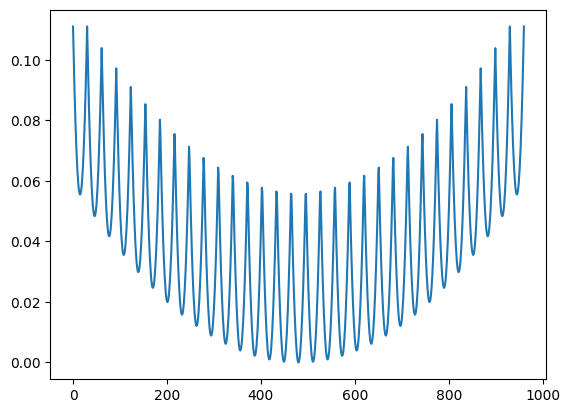

In [10]:
plt.plot((kx[0,0,0]**2 + ky[0,0,0]**2).cpu())

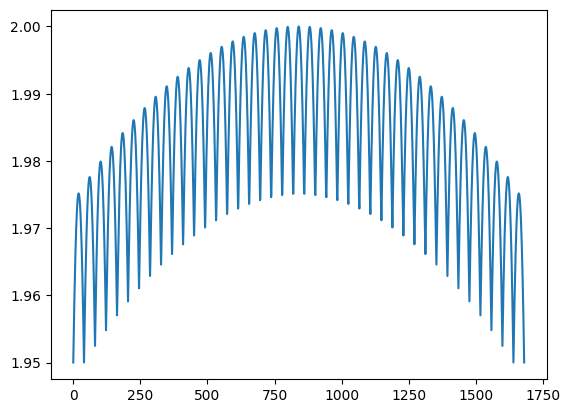

In [65]:
plt.plot((-1j*lam[0, 0, 0, :1681]).real.cpu())

In [60]:
V.shape

torch.Size([1, 1, 1, 3362, 3362])